# Cloud Infrastructure Log Anomaly Detection

**Objective:** Detect unusual service windows from error rates, latency, restarts, request volume, memory, and CPU behavior.

This notebook trains without labels. A small injected scenario flag is retained only to test the alerting workflow after scoring.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate normal behavior and rare stress scenarios


In [2]:
FEATURES = ["error_rate_pct", "p95_latency_ms", "restart_count", "requests_per_minute", "memory_pct", "cpu_pct"]
MEANS = np.asarray([1.2, 180, 0.2, 850, 58, 46], dtype=float)
STDS = np.asarray([0.6, 45, 0.5, 190, 9, 11], dtype=float)
SHIFTS = np.asarray([10, 7, 12, -3, 4, 5], dtype=float)

normal = rng.normal(MEANS, STDS, size=(960, len(FEATURES)))
stress = rng.normal(MEANS + SHIFTS * STDS, STDS * 0.55, size=(40, len(FEATURES)))
values = np.vstack([normal, stress])
values = np.maximum(values, 0)
data = pd.DataFrame(values, columns=FEATURES)
data["scenario_anomaly"] = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(stress), dtype=int)]
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset: {len(data):,} windows | stress scenarios retained for retrospective checks: {data['scenario_anomaly'].sum()}")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset: 1,000 windows | stress scenarios retained for retrospective checks: 40


,error_rate_pct,p95_latency_ms,restart_count,requests_per_minute,memory_pct,cpu_pct,scenario_anomaly
0,1.174,198.580,0.000,920.244,64.016,38.634,0
1,0.347,148.694,0.000,988.231,59.536,30.704,0
2,1.400,82.879,0.181,656.150,58.912,34.145,0
3,1.986,240.311,0.458,763.528,55.845,37.154,0
4,0.936,239.513,0.531,853.065,53.851,41.234,0


,count,mean,std,min,25%,50%,75%,max
error_rate_pct,1000.0,1.440,1.323,0.000,0.831,1.230,1.636,8.094
p95_latency_ms,1000.0,190.504,78.236,15.821,147.885,181.575,210.352,557.577
restart_count,1000.0,0.543,1.207,0.000,0.000,0.216,0.569,6.898
requests_per_minute,1000.0,834.326,219.239,0.000,712.088,840.317,987.332,1426.035
memory_pct,1000.0,59.510,11.249,29.707,52.327,58.480,64.842,101.895
cpu_pct,1000.0,47.978,15.789,0.000,38.520,46.931,54.052,111.330


## 3. Robust scaling and label-free detector fitting


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(data[FEATURES])
contamination = 0.04

isolation = IsolationForest(n_estimators=240, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
data["isolation_flag"] = (isolation.fit_predict(X) == -1).astype(int)
data["isolation_score"] = -isolation.score_samples(X)

lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
data["lof_flag"] = (lof.fit_predict(X) == -1).astype(int)
data["lof_score"] = -lof.negative_outlier_factor_
print(f"Isolation Forest alerts: {data['isolation_flag'].sum()} | LOF alerts: {data['lof_flag'].sum()}")


Isolation Forest alerts: 40 | LOF alerts: 40


## 4. Retrospective detector diagnostics


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

rows = []
for name in ["isolation", "lof"]:
    rows.append({
        "detector": name,
        "precision": precision_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "recall": recall_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "f1": f1_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "roc_auc_from_score": roc_auc_score(data["scenario_anomaly"], data[f"{name}_score"]),
    })
diagnostics = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(diagnostics.round(4))
print("Scenario labels were not used during scaling, detector fitting, or threshold selection.")


Scenario labels were not used during scaling, detector fitting, or threshold selection.


,detector,precision,recall,f1,roc_auc_from_score
0,isolation,1.0,1.0,1.0,1.0000
1,lof,0.0,0.0,0.0,0.2283


## 5. Alert queue and feature-level context


In [5]:
median = data[FEATURES].median()
mad = (data[FEATURES] - median).abs().median().replace(0, 1e-9)
robust_deviation = ((data[FEATURES] - median) / mad).abs()
data["largest_deviation_feature"] = robust_deviation.idxmax(axis=1)
data["largest_robust_deviation"] = robust_deviation.max(axis=1)
alerts = data.sort_values("isolation_score", ascending=False).head(12)
display(alerts[FEATURES + ["isolation_score", "largest_deviation_feature", "largest_robust_deviation", "scenario_anomaly"]].round(3))


,error_rate_pct,p95_latency_ms,restart_count,requests_per_minute,memory_pct,cpu_pct,isolation_score,largest_deviation_feature,largest_robust_deviation,scenario_anomaly
388,6.593,458.282,6.382,0.000,100.062,89.969,0.721,restart_count,28.591,1
662,6.722,525.731,6.087,133.419,101.895,100.593,0.696,restart_count,27.223,1
767,7.321,543.879,6.447,255.463,98.102,111.321,0.695,restart_count,28.889,1
872,7.457,494.472,6.513,417.442,99.936,108.294,0.694,restart_count,29.195,1
251,7.478,473.008,6.488,615.253,82.748,105.207,0.693,restart_count,29.083,1
605,7.182,538.785,6.347,184.688,90.396,109.317,0.691,restart_count,28.429,1
616,6.778,522.486,6.062,212.384,100.342,108.007,0.688,restart_count,27.105,1
792,8.094,465.192,5.854,179.978,93.489,106.419,0.688,restart_count,26.139,1
222,7.533,521.557,6.378,127.991,89.835,99.337,0.688,restart_count,28.572,1
152,6.858,506.945,6.033,107.673,92.577,109.015,0.686,restart_count,26.971,1


## 6. Two-dimensional anomaly map


Detector score correlation: 0.4165


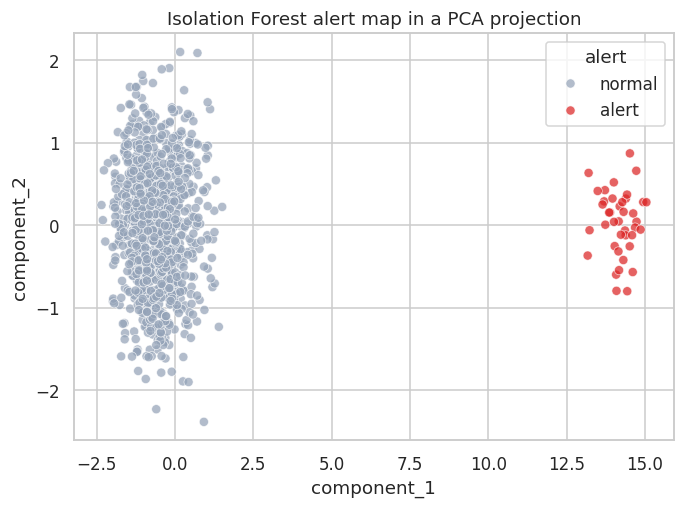

In [6]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "alert": data["isolation_flag"].map({0: "normal", 1: "alert"})})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="alert", palette={"normal": "#94a3b8", "alert": "#dc2626"}, alpha=0.72)
plt.title("Isolation Forest alert map in a PCA projection")
plt.tight_layout()
plt.show()
print(f"Detector score correlation: {data[['isolation_score', 'lof_score']].corr().iloc[0, 1]:.4f}")


## 7. Findings and limitations

- Anomaly scores prioritize investigation; they do not prove malicious activity, failure, or waste.
- The injected stress cases demonstrate evaluation mechanics only.
- Production thresholds should be calibrated to alert capacity, missed-event cost, seasonality, and feedback from investigators.
